### Section 1 – Question 1: Segment Centroids

We compute the centroids of the 8 segments by taking the mean of each numeric variable within each segment.  
Sex is encoded as **male = 1** and **female = 0**.

The table below reports the mean of:

- age  
- school  
- items  
- dollars  
- sex (encoded as male = 1, female = 0)

for each of the 8 segments.


In [1]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("segmentData.csv")

# Encode sex: male = 1, female = 0
df["sex_encoded"] = df["sex"].map({"male": 1, "female": 0})

# Numeric variables to include in the centroids
numeric_cols = ["age", "school", "items", "dollars", "sex_encoded"]

# Compute centroids: mean of each numeric variable by segment
centroids = (
    df
    .groupby("segment")[numeric_cols]
    .mean()
    .reset_index()
)

centroids


,segment,age,school,items,dollars,sex_encoded
0,1,22.66828,10.44376,1.36501,6.79798,0.50503
1,2,24.05608,15.80716,1.80906,15.51609,0.50504
2,3,34.50573,17.81266,8.50312,74.49335,0.50433
3,4,54.49724,16.36582,5.49679,61.50463,0.50580
4,5,71.86368,13.49566,2.55861,8.68422,0.25236
5,6,34.50223,13.44966,2.55283,9.57435,0.50448
6,7,44.54140,15.52418,1.81227,36.50430,0.75779
7,8,45.50983,13.50443,2.56042,11.51952,0.50709


### Section 1 – Question 2: Comparing Segments

#### **Comparison of Segments 1 and 2**
We compare the centroids of segments 1 and 2 to understand how their customers differ.  
The differences (Segment 2 minus Segment 1) show how Segment 2 customers compare on age, schooling, items purchased, dollars spent, and gender mix.

#### **Comparison of Segments 5 and 7**
We repeat the comparison for Segments 5 and 7.  
The difference table (Segment 7 minus Segment 5) indicates how Segment 7 customers differ in age, spending, and behavior.


In [2]:
cent = centroids.set_index("segment")

diff_1_2 = cent.loc[2] - cent.loc[1]
diff_1_2


age            1.38780
school         5.36340
items          0.44405
dollars        8.71811
sex_encoded    0.00001
dtype: float64

In [3]:
diff_5_7 = cent.loc[7] - cent.loc[5]
diff_5_7


age           -27.32228
school          2.02852
items          -0.74634
dollars        27.82008
sex_encoded     0.50543
dtype: float64

### Section 1 – Question 3: Targeting Millennials Who Buy Few Items

To identify which segment to focus on, we restrict the dataset to Millennials and then compute the average number of items purchased within each segment. The segment with the lowest average number of items among Millennials is the best target for the campaign.


In [4]:
# Define Millennials by age (approx. 27–44)
millennial_df = df[(df["age"] >= 27) & (df["age"] <= 44)]

# Compute mean items by segment among Millennials
millennial_items = (
    millennial_df
    .groupby("segment")["items"]
    .mean()
    .sort_values()
)

millennial_items


segment
1    1.356602
2    1.805197
7    1.809064
6    2.552830
8    2.556805
3    8.503120
Name: items, dtype: float64

### Section 2 – Question 1: Gain, Cumulative Gain, Lift, and Cumulative Lift

We compute the gain, cumulative gain, lift, and cumulative lift for each segment using dollars as the performance metric. The segments are sorted in descending order of total dollars.


In [5]:
# Total dollars by segment
seg_value = df.groupby("segment")["dollars"].sum().to_frame("segment_value")

# Gain
total_value = seg_value["segment_value"].sum()
seg_value["gain"] = seg_value["segment_value"] / total_value

# Sort by value descending
seg_sorted = seg_value.sort_values("segment_value", ascending=False).copy()
seg_sorted["rank"] = range(1, len(seg_sorted) + 1)

# Cumulative gain
seg_sorted["cum_value"] = seg_sorted["segment_value"].cumsum()
seg_sorted["cum_gain"] = seg_sorted["cum_value"] / total_value

# Expected per segment
expected_each = total_value / len(seg_sorted)

# Lift
seg_sorted["lift"] = 100 * (seg_sorted["segment_value"] / expected_each - 1)

# Cumulative lift
seg_sorted["cum_expected"] = seg_sorted["rank"] * expected_each
seg_sorted["cum_lift"] = 100 * (seg_sorted["cum_value"] / seg_sorted["cum_expected"] - 1)

seg_sorted


,segment_value,gain,rank,cum_value,cum_gain,lift,cum_expected,cum_lift
segment,,,,,,,,
3,7449335,0.331679,1,7449335,0.331679,165.343523,2807430.5,165.343523
4,6150463,0.273848,2,13599798,0.605527,119.078015,5614861.0,142.210769
7,3650430,0.162534,3,17250228,0.768061,30.027440,8422291.5,104.816326
2,1551609,0.069085,4,18801837,0.837146,-44.732060,11229722.0,67.429229
8,1151952,0.051290,5,19953789,0.888436,-58.967746,14037152.5,42.149834
6,957435,0.042630,6,20911224,0.931066,-65.896395,16844583.0,24.142129
5,868422,0.038666,7,21779646,0.969732,-69.067017,19652013.5,10.826537
1,679798,0.030268,8,22459444,1.000000,-75.785759,22459444.0,0.000000


### Section 2 – Question 2: Gain Charts and Rewards Program

We plot the gain and cumulative gain for all segments.  
The segments with the highest gain values are recommended for inclusion in a rewards program.


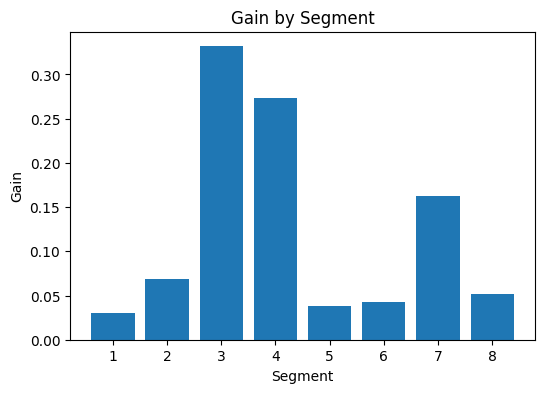

In [6]:
import matplotlib.pyplot as plt

# Bar plot: Gain
plt.figure(figsize=(6,4))
plt.bar(seg_value.index.astype(str), seg_value["gain"])
plt.xlabel("Segment")
plt.ylabel("Gain")
plt.title("Gain by Segment")
plt.show()


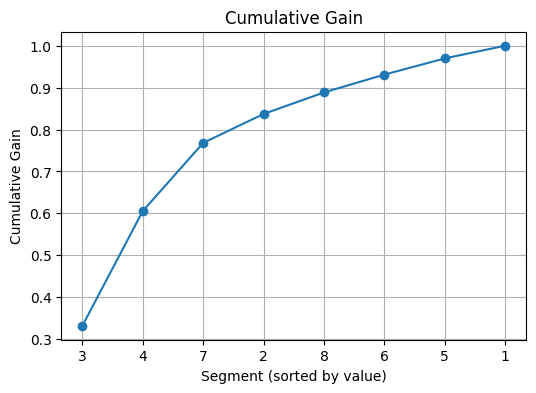

In [7]:
# Line plot: Cumulative Gain
plt.figure(figsize=(6,4))
plt.plot(seg_sorted.index.astype(str), seg_sorted["cum_gain"], marker="o")
plt.xlabel("Segment (sorted by value)")
plt.ylabel("Cumulative Gain")
plt.title("Cumulative Gain")
plt.grid(True)
plt.show()


In [8]:
# Sort segments by gain (descending)
seg_value.sort_values("gain", ascending=False)


,segment_value,gain
segment,,
3,7449335,0.331679
4,6150463,0.273848
7,3650430,0.162534
2,1551609,0.069085
8,1151952,0.051290
6,957435,0.042630
5,868422,0.038666
1,679798,0.030268


### Section 2 – Question 3: Lift Charts and Underperforming Segments

We plot the lift and cumulative lift for all segments.  
Segments with negative lift values are generating less than expected sales.


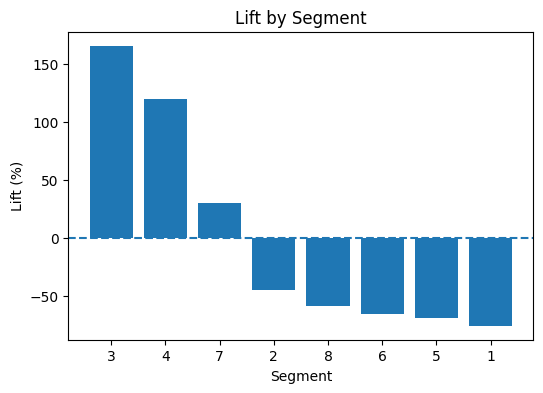

In [9]:
# Bar plot: Lift
plt.figure(figsize=(6,4))
plt.bar(seg_sorted.index.astype(str), seg_sorted["lift"])
plt.axhline(0, linestyle="--")
plt.xlabel("Segment")
plt.ylabel("Lift (%)")
plt.title("Lift by Segment")
plt.show()


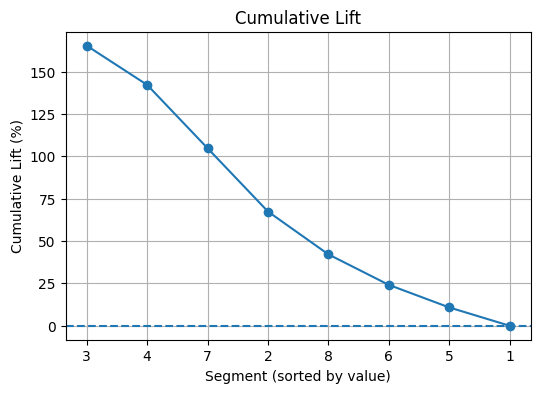

In [10]:
# Line plot: Cumulative Lift
plt.figure(figsize=(6,4))
plt.plot(seg_sorted.index.astype(str), seg_sorted["cum_lift"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Segment (sorted by value)")
plt.ylabel("Cumulative Lift (%)")
plt.title("Cumulative Lift")
plt.grid(True)
plt.show()


In [11]:
# Identify segments with negative lift
seg_sorted[seg_sorted["lift"] < 0]


,segment_value,gain,rank,cum_value,cum_gain,lift,cum_expected,cum_lift
segment,,,,,,,,
2,1551609,0.069085,4,18801837,0.837146,-44.732060,11229722.0,67.429229
8,1151952,0.051290,5,19953789,0.888436,-58.967746,14037152.5,42.149834
6,957435,0.042630,6,20911224,0.931066,-65.896395,16844583.0,24.142129
5,868422,0.038666,7,21779646,0.969732,-69.067017,19652013.5,10.826537
1,679798,0.030268,8,22459444,1.000000,-75.785759,22459444.0,0.000000
